In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [13]:
df = pd.read_csv("../data/Social_Network_Ads.csv")

In [14]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [18]:
df.loc[:,["Age","EstimatedSalary","Purchased"]]
df.sample()

,Age,EstimatedSalary,Purchased
292,55,39000,1


In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(df.drop("Purchased",axis=1),df["Purchased"],test_size=0.2,random_state=69)

In [22]:
X_train.shape, X_test.shape

((320, 2), (80, 2))

## Standard Scaler


In [ ]:
from sklearn.preprocessing import StandardScaler #formula = ( x - mean )/std

scalar= StandardScaler()

scalar.fit(X_train)

X_train_scalar = scalar.transform(X_train)
X_test_scalar = scalar.transform(X_test)

In [24]:
X_train_scalar

array([[-0.93733289,  0.45429925],
       [-1.3251112 , -0.44345143],
       [-1.90677867, -0.53322649],
       [-1.8098341 ,  0.18497404],
       [-0.25872084, -0.44345143],
       [ 0.22600205, -0.32375134],
       [ 1.00155867,  1.92062534],
       [ 0.4198912 ,  1.02287467],
       [-1.03427747, -1.49082721],
       [ 0.22600205, -0.1442012 ],
       [ 0.9046141 , -0.62300156],
       [-0.45261   , -0.02450111],
       [ 0.03211289,  0.03534893],
       [ 1.87405988,  0.125124  ],
       [-1.42205578, -0.11427618],
       [ 0.03211289, -0.1442012 ],
       [ 1.29239241,  1.92062534],
       [-1.71288952,  0.36452418],
       [-0.54955458,  1.50167503],
       [-0.06483169,  0.30467413],
       [-0.64649916,  0.125124  ],
       [-0.35566542, -1.3412021 ],
       [ 1.38933699,  1.3221249 ],
       [-0.25872084,  1.14257476],
       [-1.90677867,  0.48422427],
       [ 0.12905747, -0.32375134],
       [ 0.22600205,  1.11264974],
       [-1.03427747,  0.78347449],
       [ 0.9046141 ,

In [25]:
# conerting np array to dataframe
X_train_scalar = pd.DataFrame(X_train_scalar, columns=X_train.columns)
X_test_scalar = pd.DataFrame(X_test_scalar, columns=X_test.columns)


In [27]:
np.round(X_train.describe(),2)

,Age,EstimatedSalary
count,320.00,320.00
mean,37.67,69818.75
std,10.33,33469.19
min,18.00,15000.00
25%,30.00,43000.00
50%,37.00,70500.00
75%,45.25,88000.00
max,60.00,150000.00


In [28]:
np.round(X_train_scalar.describe(),1)

,Age,EstimatedSalary
count,320.0,320.0
mean,-0.0,-0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.7,-0.8
50%,-0.1,0.0
75%,0.7,0.5
max,2.2,2.4


## Effect of Scaling


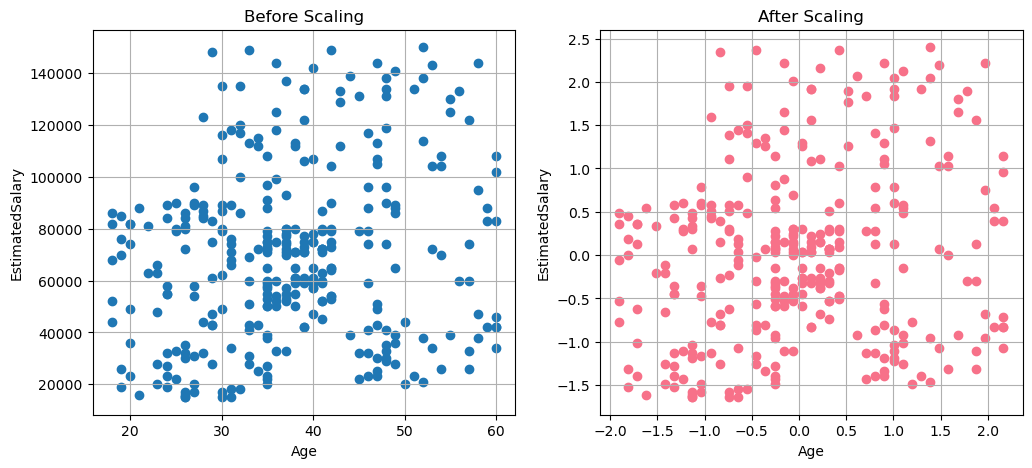

In [36]:
from turtle import color

from seaborn import color_palette


fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(X_train["Age"],X_train["EstimatedSalary"])
ax1.set_title("Before Scaling")
ax1.set_xlabel("Age")
ax1.set_ylabel("EstimatedSalary")
ax1.grid(True)

ax2.scatter(X_train_scalar["Age"],X_train_scalar["EstimatedSalary"],color=color_palette("husl",8)[0])
ax2.set_title("After Scaling")
ax2.set_xlabel("Age")
ax2.set_ylabel("EstimatedSalary")
ax2.grid(True)

## why scaling is important


In [37]:
from sklearn.linear_model import LogisticRegression

In [38]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

lr.fit(X_train, y_train)
lr_scaled.fit(X_train_scalar, y_train)

y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scalar)



In [39]:
from sklearn.metrics import accuracy_score

print("Actual: ", accuracy_score(y_test, y_pred))
print("Scaled: ", accuracy_score(y_test, y_pred_scaled))




Actual:  0.8
Scaled:  0.7875


In [40]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

dt.fit(X_train, y_train)
dt_scaled.fit(X_train_scalar, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [ ]:
y_pred = dt.predict(X_test)
y_pred_scaled = dt_scaled.predict(X_test_scalar)

print("Actual: ", accuracy_score(y_test, y_pred))
print("Scaled: ", accuracy_score(y_test, y_pred_scaled))

# it doesn't make a difference in decision tree

Actual:  0.825
Scaled:  0.825


In [44]:
new_rows = pd.DataFrame({
    "Age": [5, 90, 95],
    "EstimatedSalary": [1000, 200000, 300000],
    "Purchased": [0, 1, 1]
})

df = pd.concat([df, new_rows], ignore_index=True)

In [45]:
df.shape

(403, 3)

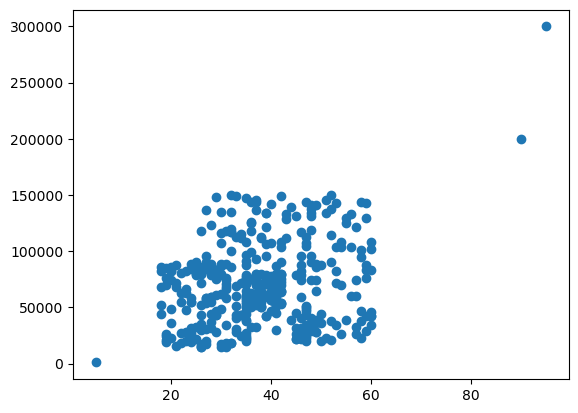

In [46]:
plt.scatter(df["Age"],df["EstimatedSalary"])

In [47]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop("Purchased",axis=1),df["Purchased"],test_size=0.2,random_state=69)
X_train.shape, X_test.shape



((322, 2), (81, 2))

In [48]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()

scalar.fit(X_train)

X_train_scalar = scalar.transform(X_train)
X_test_scalar = scalar.transform(X_test)

In [51]:
X_train_scaled = pd.DataFrame(X_train_scalar, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scalar, columns=X_test.columns)

print(np.round(X_train.describe(),2))
print()
print(np.round(X_train_scaled.describe(),1))



          Age  EstimatedSalary
count  322.00           322.00
mean    38.21         70059.01
std     11.04         36295.34
min      5.00          1000.00
25%     31.00         43250.00
50%     37.00         68000.00
75%     46.00         87750.00
max     95.00        300000.00

         Age  EstimatedSalary
count  322.0            322.0
mean    -0.0              0.0
std      1.0              1.0
min     -3.0             -1.9
25%     -0.7             -0.7
50%     -0.1             -0.1
75%      0.7              0.5
max      5.2              6.3


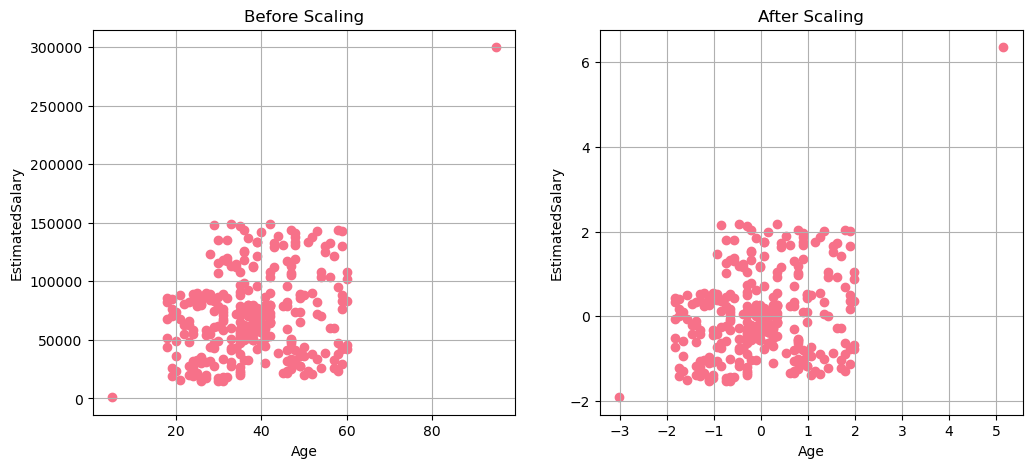

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(X_train["Age"],X_train["EstimatedSalary"])
ax1.set_title("Before Scaling")
ax1.set_xlabel("Age")
ax1.set_ylabel("EstimatedSalary")
ax1.grid(True)  

ax2.scatter(X_train_scaled["Age"],X_train_scaled["EstimatedSalary"],color=color_palette("husl",8)[0])
ax2.set_title("After Scaling")
ax2.set_xlabel("Age")
ax2.set_ylabel("EstimatedSalary")
ax2.grid(True)


In [ ]:
# when to use the StandardScaler

#algorithms 
# 1. k means
# 2. k-nearest neighbors
# 3. pca
# 4. Artificial Neural Network
# 5. Gradient Descent
